In [1]:
# Read necessary modules
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
import os
import tensorflow as tf
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
import keras

2025-11-21 11:08:46.028562: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763723326.222148      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763723326.277993      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## Preprocessing
Getting the text of disaster Tweets in the right format.

In [3]:
# Read dataset
test_df = pd.read_csv('/kaggle/input/nlp-getting-started/test.csv')
test_df

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [4]:
# Function to write model training results to an external location 
def write_away(name, model_results, path):

# Writing away the results 
    name = pd.DataFrame.from_dict(model_results)
    name.to_csv(path, index=False)
    return name

In [5]:
# Function to remove integers from selected columns
def remove_numbers(x):
    return re.sub(r'\d+', '', x)

In [6]:
# Remove integers from column text
test_df['text'] = test_df['text'].apply(remove_numbers)
test_df

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [7]:
# function to remove stopwords from nltk corpus from strings
def basic_clean(x):
  """
  A simple function to clean up the data. All the words that
  are not designated as a stop word is then lemmatized after
  encoding and basic regex parsing are performed.
  """
  stops = set(stopwords.words('english'))
  words = re.sub(r'[^\w\s]', '', x).lower().split()
  return [word for word in words if word not in stops]

In [8]:
# apply function basic_clean to column text
test_df['text'] = test_df['text'].apply(basic_clean)

# apply lambda function to put column text in right format
test_df['text'] = test_df['text'].apply(lambda x: ', '.join(x))
test_df

,id,keyword,location,text
0,0,NaN,NaN,"happened, terrible, car, crash"
1,2,NaN,NaN,"heard, earthquake, different, cities, stay, sa..."
2,3,NaN,NaN,"forest, fire, spot, pond, geese, fleeing, acro..."
3,9,NaN,NaN,"apocalypse, lighting, spokane, wildfires"
4,11,NaN,NaN,"typhoon, soudelor, kills, china, taiwan"
...,...,...,...,...
3258,10861,NaN,NaN,"earthquake, safety, los, angeles, ûò, safety, ..."
3259,10865,NaN,NaN,"storm, ri, worse, last, hurricane, cityampothe..."
3260,10868,NaN,NaN,"green, line, derailment, chicago, httptcoutbxl..."
3261,10874,NaN,NaN,"meg, issues, hazardous, weather, outlook, hwo,..."


In [9]:
# Put text and target variable in an array
x_test = np.array(test_df.text)
x_test

array(['happened, terrible, car, crash',
       'heard, earthquake, different, cities, stay, safe, everyone',
       'forest, fire, spot, pond, geese, fleeing, across, street, cannot, save',
       ..., 'green, line, derailment, chicago, httptcoutbxlcbiuy',
       'meg, issues, hazardous, weather, outlook, hwo, httptcoxrbqjhn',
       'cityofcalgary, activated, municipal, emergency, plan, yycstorm'],
      dtype=object)

## Iteration 5 Model 2
- Loading model.
- Predicting observations from test set.
- Applying labels based on score thresholds.

Model specifications can be found in 5511-pr-week-4-model-iv-gh.ipynb (Model 2). 

In [11]:
# Load model RNN II
rnn_ii_test = keras.models.load_model('/kaggle/input/5511-pr-w4/keras/default/1/RNN_II.keras')

In [12]:
# Predict observations test set with model RNN II
pred_rnn_i = rnn_ii_test.predict(x_test)
pred_rnn_i

102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


array([[0.51498353],
       [0.66907674],
       [0.73030764],
       ...,
       [0.845135  ],
       [1.0085397 ],
       [0.5422044 ]], dtype=float32)

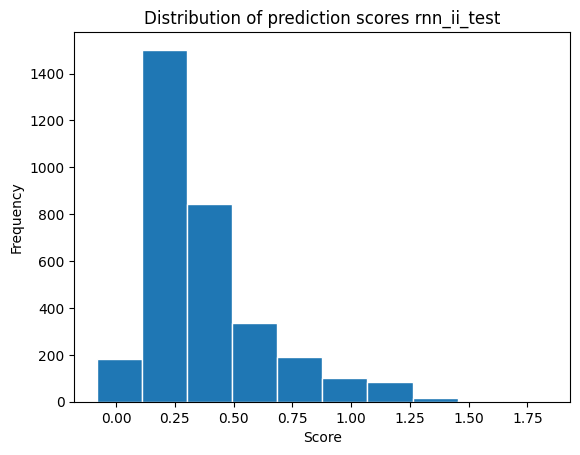

In [35]:
# Histogram of distribution scores rnn_ii_test
plt.hist(pred_rnn_i, edgecolor= 'white')
plt.ylabel('Frequency')
plt.xlabel('Score')
plt.title('Distribution of prediction scores rnn_ii_test')
plt.show()

In [13]:
# Put predictions in a dataframe
score_rnn_ii = pd.DataFrame(pred_rnn_i,columns = ['score'])
score_rnn_ii

,score
0,0.514984
1,0.669077
2,0.730308
3,0.479443
4,0.908911
...,...
3258,0.790988
3259,0.368971
3260,0.845135
3261,1.008540


In [27]:
# Add label to score_rnn_ii based on score 
# If score >= 0.5, label is 1  
score_rnn_ii['Label'] = [1 if score_ >= 0.50 else 0 for score_ in score_rnn_ii['score']]

# If score >= 0.45, label is 1
score_rnn_ii['Label_I'] = [1 if score_ >= 0.45 else 0 for score_ in score_rnn_ii['score']]
score_rnn_ii

,score,Label,Label_I
0,0.514984,1,1
1,0.669077,1,1
2,0.730308,1,1
3,0.479443,0,1
4,0.908911,1,1
...,...,...,...
3258,0.790988,1,1
3259,0.368971,0,0
3260,0.845135,1,1
3261,1.008540,1,1


## Iteration 5 Model 3
- Loading model.
- Predicting observations from test set.
- Applying labels based on score thresholds.

Model specifications can be found in 5511-pr-week-4-model-iv-gh.ipynb (Model 3). 



In [15]:
# Load model RNN III
rnn_iii_test = keras.models.load_model('/kaggle/input/5511-pr-w4/keras/default/1/RNN_III.keras')

In [17]:
# Predict observations test set with model RNN III
pred_rnn_ii = rnn_iii_test.predict(x_test)
pred_rnn_ii

102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


array([[0.47491115],
       [1.0249276 ],
       [1.6968373 ],
       ...,
       [1.490026  ],
       [1.6914566 ],
       [0.98032105]], dtype=float32)

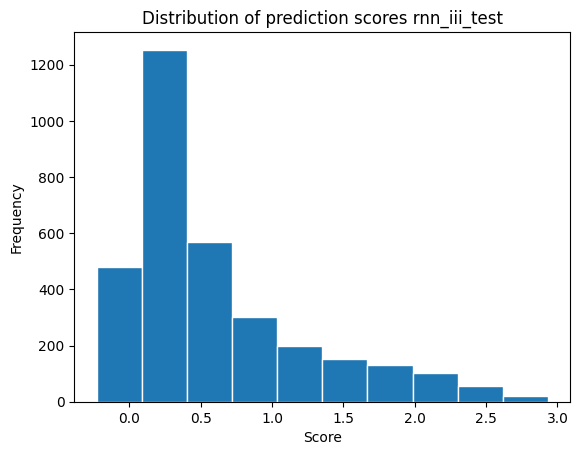

In [36]:
# Histogram of distribution scores rnn_iii_test
plt.hist(pred_rnn_ii, edgecolor= 'white')
plt.ylabel('Frequency')
plt.xlabel('Score')
plt.title('Distribution of prediction scores rnn_iii_test')
plt.show()

In [18]:
# Put predictions in a dataframe
score_rnn_iii = pd.DataFrame(pred_rnn_ii,columns = ['score'])
score_rnn_iii

,score
0,0.474911
1,1.024928
2,1.696837
3,0.640152
4,1.824731
...,...
3258,0.963530
3259,0.832492
3260,1.490026
3261,1.691457


In [19]:
# Add label to score_rnn_ii based on score 
# If score >= 0.5, label is 1  
score_rnn_iii['Label'] = [1 if score_ >= 0.50 else 0 for score_ in score_rnn_iii['score']]

# If score >= 0.45, label is 1
score_rnn_iii['Label_I'] = [1 if score_ >= 0.45 else 0 for score_ in score_rnn_iii['score']]
score_rnn_iii

,score,Label,Label_I
0,0.474911,0,1
1,1.024928,1,1
2,1.696837,1,1
3,0.640152,1,1
4,1.824731,1,1
...,...,...,...
3258,0.963530,1,1
3259,0.832492,1,1
3260,1.490026,1,1
3261,1.691457,1,1


## Kaggle Submission
Getting the predictions ready for submission to Kaggle.

In [21]:
# Make a dataframe of identifiers for Kaggle submission
identifier = pd.DataFrame(test_df.id)

In [29]:
# Kaggle submission for score_rnn_ii with threshold of 0.5
solution_rnn1_05 = identifier.join(score_rnn_ii.Label)
solution_rnn1_05.rename(columns= {'Label': 'target'}, inplace = True)

solution_rnn1_05.to_csv('/kaggle/working/pred_rnn1_05.csv', index=False)

In [30]:
# Kaggle submission for score_rnn_ii with threshold of 0.45
solution_rnn1_045 = identifier.join(score_rnn_ii.Label_I)
solution_rnn1_045.rename(columns= {'Label_I': 'target'}, inplace = True)

solution_rnn1_045.to_csv('/kaggle/working/pred_rnn1_045.csv', index=False)

In [37]:
# Kaggle submission for score_rnn_iii with threshold of 0.5
solution_rnn2_05 = identifier.join(score_rnn_iii.Label)
solution_rnn2_05.rename(columns= {'Label': 'target'}, inplace = True)

solution_rnn2_05.to_csv('/kaggle/working/pred_rnn2_05.csv', index=False)

In [38]:
# Kaggle submission for score_rnn_iii with threshold of 0.45
solution_rnn2_045 = identifier.join(score_rnn_iii.Label_I)
solution_rnn2_045.rename(columns= {'Label_I': 'target'}, inplace = True)

solution_rnn2_045.to_csv('/kaggle/working/pred_rnn2_045.csv', index=False)